# Predicción del Precio de Bitcoin con LSTM Bidireccional

---

**Dataset:** Bitcoin (BTC/USDT) — Binance Historical Price Data  
**Objetivo:** Predecir el precio de cierre del BTC usando modelos secuenciales  
**Modelos comparados:** MLP · LSTM · LSTM Bidireccional  
**Framework:** PyTorch

---

> Este cuadernillo forma parte de la práctica de Redes Neuronales Recurrentes. Se sigue la estructura de los cuadernillos de referencia `01_rnn_intro` y `02_rnn_forecast`, aplicada a un dataset real de precios de criptomonedas.

## 1. Motivación: ¿Por qué un LSTM Bidireccional para Bitcoin?

El precio de Bitcoin es una **serie temporal financiera** con características que hacen al LSTM Bidireccional especialmente útil:

- **Alta volatilidad y patrones no lineales**: el BTC no sigue distribuciones normales.
- **Dependencias temporales largas**: un movimiento de precio puede tener causas varios días atrás.
- **Contexto futuro en ventanas**: al predecir con una ventana deslizante, el modelo puede aprender de la estructura completa del patrón, no solo del pasado inmediato.

Un **LSTM Bidireccional** procesa la secuencia en **ambas direcciones** (pasado → futuro y futuro → pasado), capturando dependencias que un LSTM unidireccional pierde. Aunque en producción real no conocemos el futuro, en el entrenamiento por ventanas esta arquitectura mejora la representación aprendida.

![BiLSTM](https://miro.medium.com/max/1400/1*6QnPUSv_t9BY9Fv8_aLb-Q.png)

> **Nota:** Este cuadernillo **no es NLP**. Usamos BiLSTM para predicción de series temporales financieras — un dominio completamente diferente pero igualmente válido para esta arquitectura.

## 2. Instalación e Importación de Librerías

### Librerías utilizadas

| Librería | Versión | Uso |
|---|---|---|
| `torch` | ≥2.0 | Framework principal de deep learning |
| `pandas` | ≥1.5 | Carga y manipulación del dataset CSV |
| `numpy` | ≥1.23 | Operaciones numéricas y ventanas deslizantes |
| `matplotlib` | ≥3.6 | Visualizaciones de series y resultados |
| `scikit-learn` | ≥1.2 | Métricas (MSE, MAE) y normalización (MinMaxScaler) |
| `tqdm` | ≥4.64 | Barra de progreso durante el entrenamiento |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')



In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tqdm import tqdm

# ── Semilla para reproducibilidad ───────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Dispositivo de cómputo ───────────────────────────────────────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✔ Usando dispositivo: {device}")
print(f"✔ PyTorch versión: {torch.__version__}")

✔ Usando dispositivo: cuda
✔ PyTorch versión: 2.10.0+cu126


## 3. Carga y Exploración del Dataset

El dataset contiene datos históricos de precios de **BTC/USDT** de Binance. Trabajamos con el intervalo **diario (1d)** que provee:

- `Open time`: timestamp de apertura (UTC)
- `Open`, `High`, `Low`, `Close`: precios OHLC
- `Volume`: volumen de trading en BTC
- `Quote asset volume`: volumen en USDT
- `Number of trades`: número de transacciones
- `Taker buy base/quote asset volume`: volumen de órdenes de compra

**Variable objetivo:** `Close` (precio de cierre diario)

In [3]:
# ── Carga del Dataset

CSV_PATH = "btc_1d_data_2018_to_2025.csv" 

# ── Si no hay archivo local, generamos datos sintéticos realistas ────────────
import os
if not os.path.exists(CSV_PATH):
    print("⚠ Archivo CSV no encontrado. Generando dataset sintético de BTC para demo...")
    # Simulación de precio BTC con movimiento Browniano Geométrico (GBM)
    np.random.seed(SEED)
    n_days = 1500
    dates = pd.date_range(start='2019-01-01', periods=n_days, freq='D')
    
    # GBM: S_t = S_{t-1} * exp((mu - 0.5*sigma^2)*dt + sigma*sqrt(dt)*Z)
    mu, sigma, S0 = 0.0008, 0.04, 3500.0  # parámetros típicos de BTC
    returns = np.random.normal(mu - 0.5 * sigma**2, sigma, n_days)
    prices = S0 * np.exp(np.cumsum(returns))
    
    volume = np.abs(np.random.normal(30000, 8000, n_days))
    high = prices * (1 + np.abs(np.random.normal(0, 0.015, n_days)))
    low  = prices * (1 - np.abs(np.random.normal(0, 0.015, n_days)))
    opn  = prices * (1 + np.random.normal(0, 0.005, n_days))
    
    df = pd.DataFrame({
        'Open time': dates,
        'Open': opn,
        'High': high,
        'Low': low,
        'Close': prices,
        'Volume': volume,
        'Number of trades': np.random.randint(5000, 80000, n_days).astype(float)
    })
    print(f"✔ Dataset sintético generado: {len(df)} días")
else:
    df = pd.read_csv(CSV_PATH)
    df['Open time'] = pd.to_datetime(df['Open time'])
    print(f"✔ Dataset cargado: {len(df)} filas")

# ── Ordenar por fecha ────────────────────────────────────────────────────────
df = df.sort_values('Open time').reset_index(drop=True)

print(f"\n📅 Rango temporal: {df['Open time'].min().date()} → {df['Open time'].max().date()}")
print(f"📊 Shape: {df.shape}")
df.head()

✔ Dataset cargado: 2997 filas

📅 Rango temporal: 2018-01-01 → 2026-03-16
📊 Shape: (2997, 12)


,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
0,2018-01-01 00:00:00+00:00,13715.65,13818.55,12750.00,13380.00,8609.915844,2018-01-01 23:59:59.999000 UTC,1.147997e+08,105595,3961.938946,5.280975e+07,0
1,2018-01-02 00:00:00+00:00,13382.16,15473.49,12890.02,14675.11,20078.092111,2018-01-02 23:59:59.999000 UTC,2.797171e+08,177728,11346.326739,1.580801e+08,0
2,2018-01-03 00:00:00+00:00,14690.00,15307.56,14150.00,14919.51,15905.667639,2018-01-03 23:59:59.999000 UTC,2.361169e+08,162787,8994.953566,1.335873e+08,0
3,2018-01-04 00:00:00+00:00,14919.51,15280.00,13918.04,15059.54,21329.649574,2018-01-04 23:59:59.999000 UTC,3.127816e+08,170310,12680.812951,1.861168e+08,0
4,2018-01-05 00:00:00+00:00,15059.56,17176.24,14600.00,16960.39,23251.491125,2018-01-05 23:59:59.999000 UTC,3.693220e+08,192969,13346.622293,2.118299e+08,0


In [4]:
# ── Estadísticas Descriptivas ────────────────────────────────────────────────
print("\n📈 Estadísticas descriptivas del precio Close:")
print(df[['Open','High','Low','Close','Volume']].describe().round(2))

# ── Verificar valores nulos ──────────────────────────────────────────────────
print(f"\n🔍 Valores nulos: {df.isnull().sum().sum()}")


📈 Estadísticas descriptivas del precio Close:
            Open       High        Low      Close     Volume
count    2997.00    2997.00    2997.00    2997.00    2997.00
mean    38256.57   38969.96   37493.55   38289.64   62699.72
std     32486.25   32851.95   32108.27   32509.53   77836.82
min      3211.71    3276.50    3156.26    3211.72     165.22
25%      9575.00    9759.82    9281.54    9574.21   24611.24
50%     28170.01   28650.00   27662.79   28171.87   40269.89
75%     59359.00   61117.63   58034.01   59415.00   67059.29
max    124658.54  125082.27  124600.00  125046.94  760705.36

🔍 Valores nulos: 0


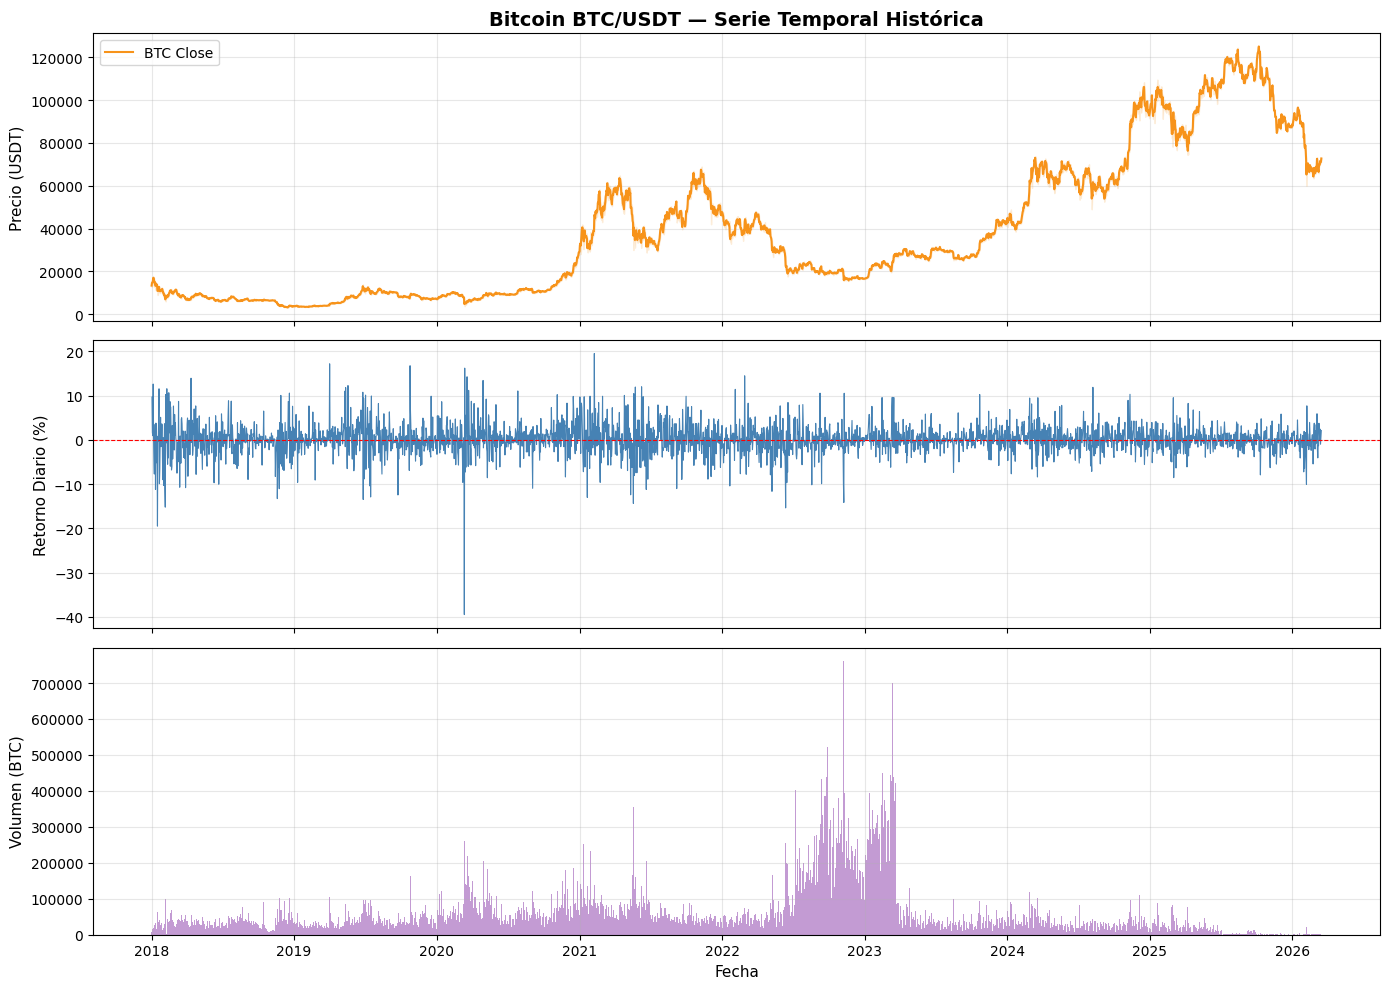

✔ Gráfico guardado como btc_historical.png


In [5]:
# ── Visualización del precio histórico ──────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Precio Close
axes[0].plot(df['Open time'], df['Close'], color='#F7931A', linewidth=1.5, label='BTC Close')
axes[0].fill_between(df['Open time'], df['Low'], df['High'], alpha=0.15, color='#F7931A')
axes[0].set_ylabel('Precio (USDT)', fontsize=11)
axes[0].set_title('Bitcoin BTC/USDT — Serie Temporal Histórica', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Retornos diarios
returns = df['Close'].pct_change().dropna()
axes[1].plot(df['Open time'][1:], returns * 100, color='steelblue', linewidth=0.8)
axes[1].axhline(0, color='red', linestyle='--', linewidth=0.8)
axes[1].set_ylabel('Retorno Diario (%)', fontsize=11)
axes[1].grid(alpha=0.3)

# Volumen
axes[2].bar(df['Open time'], df['Volume'], color='#9B59B6', alpha=0.6, width=1)
axes[2].set_ylabel('Volumen (BTC)', fontsize=11)
axes[2].set_xlabel('Fecha', fontsize=11)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('btc_historical.png', dpi=120, bbox_inches='tight')
plt.show()
print("✔ Gráfico guardado como btc_historical.png")

## 4. Preprocesamiento: Features, Normalización y Ventanas Deslizantes

### 4.1 Ingeniería de Features

Usamos múltiples features técnicas para enriquecer la información de entrada:

| Feature | Descripción |
|---|---|
| `Close` | Precio de cierre (variable objetivo) |
| `Return` | Retorno porcentual diario: $(P_t - P_{t-1}) / P_{t-1}$ |
| `HL_ratio` | Amplitud vela: $(High - Low) / Close$ |
| `OC_ratio` | Dirección vela: $(Close - Open) / Open$ |
| `Volume_norm` | Volumen normalizado por su media móvil 7d |
| `MA7` | Media móvil de 7 días |
| `MA21` | Media móvil de 21 días |
| `Volatility` | Desviación estándar de retornos en ventana 7d |

### 4.2 Ventana Deslizante (Sliding Window)

Convertimos la serie temporal en pares (X, y) donde:
- **X**: ventana de `WINDOW_SIZE` pasos temporales → shape `(N, WINDOW_SIZE, n_features)`
- **y**: el precio de cierre del paso siguiente → shape `(N, 1)`

### 4.3 Normalización

Usamos `MinMaxScaler` para escalar cada feature al rango [0, 1]. **Importante:** el scaler se ajusta **solo** con el conjunto de entrenamiento para evitar *data leakage*.

In [6]:
# ── 4.1 Ingeniería de Features ───────────────────────────────────────────────

df_feat = df[['Open time', 'Open', 'High', 'Low', 'Close', 'Volume']].copy()

# Retorno diario
df_feat['Return']      = df_feat['Close'].pct_change()
# Amplitud de la vela (High-Low) relativa al cierre
df_feat['HL_ratio']    = (df_feat['High'] - df_feat['Low']) / df_feat['Close']
# Dirección de la vela (Open-Close)
df_feat['OC_ratio']    = (df_feat['Close'] - df_feat['Open']) / df_feat['Open']
# Volumen normalizado respecto a media móvil de 7 días
df_feat['Volume_norm'] = df_feat['Volume'] / df_feat['Volume'].rolling(7).mean()
# Medias móviles
df_feat['MA7']         = df_feat['Close'].rolling(7).mean() / df_feat['Close']
df_feat['MA21']        = df_feat['Close'].rolling(21).mean() / df_feat['Close']
# Volatilidad (std de retornos en ventana 7d)
df_feat['Volatility']  = df_feat['Return'].rolling(7).std()

# Eliminar filas con NaN (introducidas por rolling y pct_change)
df_feat = df_feat.dropna().reset_index(drop=True)

print(f"✔ Features creadas. Dataset final: {df_feat.shape}")
print("\nFeatures disponibles:")
FEATURE_COLS = ['Close', 'Return', 'HL_ratio', 'OC_ratio', 'Volume_norm', 'MA7', 'MA21', 'Volatility']
print(FEATURE_COLS)
df_feat[FEATURE_COLS].describe().round(4)

✔ Features creadas. Dataset final: (2977, 13)

Features disponibles:
['Close', 'Return', 'HL_ratio', 'OC_ratio', 'Volume_norm', 'MA7', 'MA21', 'Volatility']


,Close,Return,HL_ratio,OC_ratio,Volume_norm,MA7,MA21,Volatility
count,2977.0000,2977.0000,2977.0000,2977.0000,2977.0000,2977.0000,2977.0000,2977.0000
mean,38453.5723,0.0012,0.0459,0.0013,1.0061,0.9999,1.0005,0.0294
std,32556.4406,0.0338,0.0372,0.0333,0.4358,0.0474,0.0920,0.0170
min,3211.7200,-0.3950,0.0015,-0.3951,0.0316,0.8400,0.7086,0.0031
25%,9529.9300,-0.0135,0.0227,-0.0119,0.7440,0.9748,0.9489,0.0180
50%,28424.7000,0.0004,0.0376,0.0007,0.9414,0.9983,0.9969,0.0258
75%,59860.0000,0.0153,0.0579,0.0143,1.1900,1.0202,1.0423,0.0371
max,125046.9400,0.1954,0.7409,0.1954,4.5277,1.6253,1.8024,0.1764


In [7]:
# ── 4.2 División Train/Validation/Test ──────────────────────────────────────
# Ratios: 70% train | 15% val | 15% test (sin shuffle — datos temporales)

N = len(df_feat)
train_end = int(N * 0.70)
val_end   = int(N * 0.85)

data_values = df_feat[FEATURE_COLS].values  # shape (N, 8)

train_data = data_values[:train_end]
val_data   = data_values[train_end:val_end]
test_data  = data_values[val_end:]

print(f"Train: {len(train_data)} días")
print(f"Valid: {len(val_data)} días")
print(f"Test:  {len(test_data)} días")

# ── 4.3 Normalización (fit solo en train) ───────────────────────────────────
# MinMaxScaler escala cada feature al rango [0, 1]:
# X_scaled = (X - X_min) / (X_max - X_min)
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)  # ajustar Y transformar
val_scaled   = scaler.transform(val_data)         # solo transformar
test_scaled  = scaler.transform(test_data)         # solo transformar

# Scaler solo para el precio Close (índice 0) — usado para desnormalizar predicciones
close_scaler = MinMaxScaler(feature_range=(0, 1))
close_scaler.fit(train_data[:, 0:1])

print(f"\n✔ Normalización aplicada. Rango post-escalado: [{train_scaled.min():.3f}, {train_scaled.max():.3f}]")

Train: 2083 días
Valid: 447 días
Test:  447 días

✔ Normalización aplicada. Rango post-escalado: [0.000, 1.000]


In [8]:
# ── 4.4 Ventanas Deslizantes ─────────────────────────────────────────────────
# Hiperparámetro clave:
WINDOW_SIZE = 30  # usamos los últimos 30 días para predecir el siguiente

def create_sequences(data, window_size):
    """
    Convierte una serie temporal normalizada en pares (X, y) mediante
    una ventana deslizante.
    
    Parámetros:
    -----------
    data        : np.ndarray, shape (T, n_features)
    window_size : int, número de pasos temporales en la ventana de entrada
    
    Retorna:
    --------
    X : np.ndarray, shape (N, window_size, n_features)
    y : np.ndarray, shape (N,)  → precio Close del paso siguiente
    """
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i : i + window_size])        # ventana de entrada
        y.append(data[i + window_size, 0])          # Close del siguiente paso
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train, y_train = create_sequences(train_scaled, WINDOW_SIZE)
X_val,   y_val   = create_sequences(val_scaled,   WINDOW_SIZE)
X_test,  y_test  = create_sequences(test_scaled,  WINDOW_SIZE)

print(f"X_train shape: {X_train.shape}  →  (samples, window_size, n_features)")
print(f"y_train shape: {y_train.shape}")
print(f"X_val   shape: {X_val.shape}")
print(f"X_test  shape: {X_test.shape}")

X_train shape: (2053, 30, 8)  →  (samples, window_size, n_features)
y_train shape: (2053,)
X_val   shape: (417, 30, 8)
X_test  shape: (417, 30, 8)


In [9]:
# ── Dataset y DataLoader ─────────────────────────────────────────────────────

class BTCDataset(Dataset):
    """
    Dataset PyTorch para series temporales de BTC.
    Convierte arrays numpy a tensores float32 y los empaqueta
    para ser consumidos por un DataLoader con mini-batches.
    """
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)  # (N, window, features)
        self.y = torch.tensor(y, dtype=torch.float32)  # (N,)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 64  # mini-batch estándar para estabilidad del gradiente

dataloaders = {
    'train': DataLoader(BTCDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True),
    'val':   DataLoader(BTCDataset(X_val,   y_val),   batch_size=BATCH_SIZE, shuffle=False),
    'test':  DataLoader(BTCDataset(X_test,  y_test),  batch_size=BATCH_SIZE, shuffle=False),
}

print(f"✔ DataLoaders creados — Batch size: {BATCH_SIZE}")
print(f"   Train batches: {len(dataloaders['train'])}")
print(f"   Val   batches: {len(dataloaders['val'])}")
print(f"   Test  batches: {len(dataloaders['test'])}")

✔ DataLoaders creados — Batch size: 64
   Train batches: 33
   Val   batches: 7
   Test  batches: 7


## 5. Definición de Modelos

Implementamos tres modelos para comparar sus prestaciones:

### 5.1 MLP (Perceptrón Multicapa) — Línea de Base

El MLP recibe la ventana completa **aplanada** como vector y aplica capas densas. **No tiene noción de orden temporal** — trata cada paso como una feature independiente. Sirve como *baseline* para demostrar la ventaja de los modelos recurrentes.

### 5.2 LSTM (Long Short-Term Memory)

El LSTM es una RNN especial que resuelve el problema del **gradiente evanescente** mediante celdas de memoria con tres puertas:
- **Puerta de olvido** (forget gate): decide qué información descartar
- **Puerta de entrada** (input gate): decide qué nueva información almacenar  
- **Puerta de salida** (output gate): controla qué parte del estado de celda se produce a la salida

### 5.3 BiLSTM (LSTM Bidireccional) ⭐

Extiende el LSTM procesando la secuencia en **dos direcciones** simultáneamente:
- **LSTM hacia adelante**: procesa $x_1 \to x_2 \to \dots \to x_T$
- **LSTM hacia atrás**: procesa $x_T \to x_{T-1} \to \dots \to x_1$

Las salidas de ambas direcciones se **concatenan**, duplicando la dimensión de hidden state. Esto permite que cada paso temporal tenga contexto tanto del pasado como del futuro dentro de la ventana de entrada.

In [10]:
# ── 5.1 Modelo MLP (Baseline) ────────────────────────────────────────────────

class MLP(nn.Module):
    """
    Perceptrón Multicapa para predicción de series temporales.
    
    Arquitectura:
      - Aplana la ventana de entrada (window_size * n_features)
      - Tres capas densas con activación ReLU y Dropout
      - Capa de salida con 1 neurona (regresión)
    
    Hiperparámetros:
      input_size  : window_size * n_features = 30 * 8 = 240
      hidden_size : 128 neuronas por capa oculta
      dropout     : 0.2 — regularización para evitar sobreajuste
    """
    def __init__(self, window_size=30, n_features=8, hidden_size=128, dropout=0.2):
        super().__init__()
        input_size = window_size * n_features
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, 1)
        )

    def forward(self, x):
        # x: (batch, window_size, n_features) → aplanar → (batch, input_size)
        x = x.view(x.size(0), -1)
        return self.net(x).squeeze(-1)


# Conteo de parámetros
mlp_model = MLP(window_size=WINDOW_SIZE, n_features=len(FEATURE_COLS))
n_params_mlp = sum(p.numel() for p in mlp_model.parameters() if p.requires_grad)
print(f"MLP — Parámetros entrenables: {n_params_mlp:,}")
print(mlp_model)

MLP — Parámetros entrenables: 39,169
MLP(
  (net): Sequential(
    (0): Linear(in_features=240, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [11]:
# ── 5.2 Modelo LSTM ──────────────────────────────────────────────────────────

class LSTMModel(nn.Module):
    """
    LSTM para predicción de series temporales.
    
    Arquitectura:
      - 2 capas LSTM apiladas (stacked LSTM) con hidden_size neuronas
      - Dropout entre capas para regularización
      - Capa densa FC sobre la última salida temporal → 1 valor
    
    Hiperparámetros:
      n_features  : número de features de entrada (8)
      hidden_size : 64 neuronas en el estado oculto
      num_layers  : 2 capas LSTM apiladas (Deep LSTM)
      dropout     : 0.2 — aplicado entre capas LSTM
      batch_first : True — formato (batch, seq, features)
    """
    def __init__(self, n_features=8, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,     # input: (batch, seq_len, input_size)
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, window_size, n_features)
        out, (h_n, c_n) = self.lstm(x)
        # Tomar solo la salida del último paso temporal
        last_out = out[:, -1, :]      # (batch, hidden_size)
        return self.fc(last_out).squeeze(-1)  # (batch,)


lstm_model = LSTMModel(n_features=len(FEATURE_COLS))
n_params_lstm = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(f"LSTM — Parámetros entrenables: {n_params_lstm:,}")
print(lstm_model)

LSTM — Parámetros entrenables: 52,289
LSTMModel(
  (lstm): LSTM(8, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [12]:
# ── 5.3 Modelo BiLSTM ⭐ ─────────────────────────────────────────────────────

class BiLSTMModel(nn.Module):
    """
    LSTM Bidireccional para predicción de series temporales.
    
    Arquitectura:
      - 2 capas BiLSTM apiladas
      - bidirectional=True → duplica el hidden_size en la salida
        (forward hidden + backward hidden concatenados)
      - LayerNorm antes de la capa final — estabiliza el entrenamiento
      - Capa densa FC: 2*hidden_size → 1
    
    Hiperparámetros:
      n_features    : 8 features de entrada
      hidden_size   : 64 neuronas por dirección (128 total en salida)
      num_layers    : 2 capas BiLSTM
      dropout       : 0.2
      bidirectional : True ← diferencia clave vs LSTM
    """
    def __init__(self, n_features=8, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.bilstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True    # ← CLAVE: procesa en ambas direcciones
        )
        # La salida tiene dimensión 2 * hidden_size (forward + backward)
        self.norm = nn.LayerNorm(hidden_size * 2)
        self.fc   = nn.Linear(hidden_size * 2, 1)

    def forward(self, x):
        # x: (batch, window_size, n_features)
        out, _ = self.bilstm(x)
        # out: (batch, window_size, 2 * hidden_size)
        last_out = out[:, -1, :]            # último paso temporal
        last_out = self.norm(last_out)      # normalización de capa
        return self.fc(last_out).squeeze(-1)


bilstm_model = BiLSTMModel(n_features=len(FEATURE_COLS))
n_params_bilstm = sum(p.numel() for p in bilstm_model.parameters() if p.requires_grad)
print(f"BiLSTM — Parámetros entrenables: {n_params_bilstm:,}")
print(bilstm_model)

BiLSTM — Parámetros entrenables: 137,601
BiLSTMModel(
  (bilstm): LSTM(8, 64, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
  (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


In [13]:
# ── Tabla comparativa de arquitecturas ──────────────────────────────────────
print("\n" + "="*65)
print(f"{'Modelo':<12} {'Tipo':<20} {'Parámetros':>12} {'Procesa orden':>15}")
print("="*65)
print(f"{'MLP':<12} {'Feed-forward':<20} {n_params_mlp:>12,} {'No':>15}")
print(f"{'LSTM':<12} {'Recurrente':<20} {n_params_lstm:>12,} {'Sí (→)':>15}")
print(f"{'BiLSTM':<12} {'Recurrente Bidirecional':<20} {n_params_bilstm:>12,} {'Sí (↔)':>15}")
print("="*65)


Modelo       Tipo                   Parámetros   Procesa orden
MLP          Feed-forward               39,169              No
LSTM         Recurrente                 52,289          Sí (→)
BiLSTM       Recurrente Bidirecional      137,601          Sí (↔)


## 6. Entrenamiento

### Función de pérdida y optimizador

- **Función de pérdida:** `MSELoss` (Error Cuadrático Medio) — estándar para regresión
- **Optimizador:** `Adam` con `lr=1e-3` — adaptativo, converge rápido y es robusto
- **Scheduler:** `ReduceLROnPlateau` — reduce el learning rate si la validación no mejora en 5 épocas (*patience=5*, *factor=0.5*)
- **Early Stopping:** detiene el entrenamiento si la pérdida de validación no mejora en 10 épocas, guardando el mejor modelo

### Hiperparámetros de entrenamiento

| Hiperparámetro | Valor | Descripción |
|---|---|---|
| `epochs` | 60 | Número máximo de épocas |
| `batch_size` | 64 | Muestras por mini-batch |
| `learning_rate` | 1e-3 | Tasa de aprendizaje inicial |
| `patience` | 10 | Épocas sin mejora antes de early stop |
| `scheduler_patience` | 5 | Épocas sin mejora para reducir LR |

In [14]:
# ── Función de Entrenamiento ─────────────────────────────────────────────────

def train_model(model, dataloaders, epochs=60, lr=1e-3, patience=10, model_name="Model"):
    """
    Entrena un modelo PyTorch con early stopping y scheduler de LR.
    
    Parámetros:
    -----------
    model       : nn.Module — modelo a entrenar
    dataloaders : dict con 'train' y 'val' DataLoaders
    epochs      : int — número máximo de épocas
    lr          : float — learning rate inicial
    patience    : int — épocas sin mejora para early stopping
    model_name  : str — nombre para logs
    
    Retorna:
    --------
    history : dict con listas 'train_loss' y 'val_loss' por época
    """
    model.to(device)
    
    # Optimizador Adam: combina momentum y RMSProp — efectivo para series temporales
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    # Criterion: MSE — penaliza errores grandes cuadráticamente
    criterion = nn.MSELoss()
    
    # Scheduler: reduce LR en factor 0.5 si la val_loss no mejora en 5 épocas
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )
    
    history = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    best_weights  = None
    no_improve    = 0
    
    bar = tqdm(range(1, epochs + 1), desc=f"Entrenando {model_name}")
    
    for epoch in bar:
        # ── Fase de entrenamiento ────────────────────────────────────────────
        model.train()
        train_losses = []
        for X_batch, y_batch in dataloaders['train']:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()          # limpiar gradientes
            y_hat = model(X_batch)         # forward pass
            loss  = criterion(y_hat, y_batch)  # calcular pérdida
            loss.backward()                # backpropagation
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # clip gradientes
            optimizer.step()               # actualizar pesos
            train_losses.append(loss.item())
        
        # ── Fase de validación ───────────────────────────────────────────────
        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, y_batch in dataloaders['val']:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                y_hat = model(X_batch)
                val_losses.append(criterion(y_hat, y_batch).item())
        
        avg_train = np.mean(train_losses)
        avg_val   = np.mean(val_losses)
        history['train_loss'].append(avg_train)
        history['val_loss'].append(avg_val)
        
        scheduler.step(avg_val)  # ajustar LR según validación
        
        bar.set_postfix({'train': f'{avg_train:.5f}', 'val': f'{avg_val:.5f}',
                         'lr': f'{optimizer.param_groups[0]["lr"]:.2e}'})
        
        # ── Early Stopping ───────────────────────────────────────────────────
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            best_weights  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve    = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"\n⏹ Early stopping en época {epoch} (mejor val_loss: {best_val_loss:.6f})")
                break
    
    # Restaurar el mejor modelo
    model.load_state_dict({k: v.to(device) for k, v in best_weights.items()})
    print(f"✔ Mejor val_loss {model_name}: {best_val_loss:.6f}")
    return history


# ── Función de predicción ────────────────────────────────────────────────────
def predict_model(model, dataloader):
    """
    Genera predicciones en modo evaluación (sin dropout, sin gradientes).
    Retorna un array numpy con las predicciones desnormalizadas.
    """
    model.eval()
    preds = []
    with torch.no_grad():
        for X_batch, _ in dataloader:
            X_batch = X_batch.to(device)
            preds.append(model(X_batch).cpu().numpy())
    return np.concatenate(preds)

In [15]:
# ── Entrenamiento de los tres modelos ────────────────────────────────────────
EPOCHS = 60

print("=" * 50)
print("ENTRENANDO MLP")
print("=" * 50)
mlp_model = MLP(window_size=WINDOW_SIZE, n_features=len(FEATURE_COLS))
history_mlp = train_model(mlp_model, dataloaders, epochs=EPOCHS, model_name="MLP")

print("\n" + "=" * 50)
print("ENTRENANDO LSTM")
print("=" * 50)
lstm_model = LSTMModel(n_features=len(FEATURE_COLS))
history_lstm = train_model(lstm_model, dataloaders, epochs=EPOCHS, model_name="LSTM")

print("\n" + "=" * 50)
print("ENTRENANDO BiLSTM ⭐")
print("=" * 50)
bilstm_model = BiLSTMModel(n_features=len(FEATURE_COLS))
history_bilstm = train_model(bilstm_model, dataloaders, epochs=EPOCHS, model_name="BiLSTM")

ENTRENANDO MLP


Entrenando MLP:  72%|███████▏  | 43/60 [00:05<00:02,  7.23it/s, train=0.00169, val=0.00342, lr=2.50e-04]



⏹ Early stopping en época 44 (mejor val_loss: 0.001815)
✔ Mejor val_loss MLP: 0.001815

ENTRENANDO LSTM


Entrenando LSTM:  62%|██████▏   | 37/60 [00:06<00:03,  5.87it/s, train=0.00041, val=0.00352, lr=5.00e-04]



⏹ Early stopping en época 38 (mejor val_loss: 0.002406)
✔ Mejor val_loss LSTM: 0.002406

ENTRENANDO BiLSTM ⭐


Entrenando BiLSTM:  22%|██▏       | 13/60 [00:02<00:09,  4.75it/s, train=0.00048, val=0.00142, lr=5.00e-04]


⏹ Early stopping en época 14 (mejor val_loss: 0.001195)
✔ Mejor val_loss BiLSTM: 0.001195


## 7. Curvas de Aprendizaje

Las curvas de aprendizaje nos permiten diagnosticar el comportamiento del entrenamiento:

- **Convergencia**: ¿cuántas épocas tarda en estabilizarse la pérdida?
- **Sobreajuste**: ¿hay brecha entre train y val?
- **Capacidad**: ¿el modelo tiene suficientes parámetros?

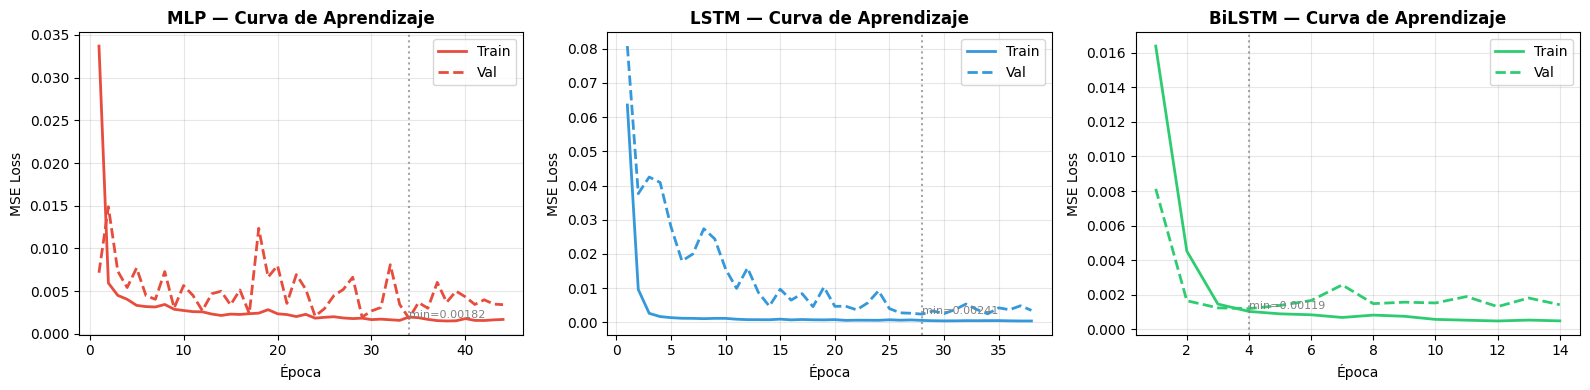

✔ Curvas de aprendizaje guardadas


In [16]:
# ── Curvas de aprendizaje ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
configs = [
    (history_mlp,    'MLP',    '#E74C3C'),
    (history_lstm,   'LSTM',   '#3498DB'),
    (history_bilstm, 'BiLSTM', '#2ECC71'),
]

for ax, (hist, name, color) in zip(axes, configs):
    epochs_ran = range(1, len(hist['train_loss']) + 1)
    ax.plot(epochs_ran, hist['train_loss'], color=color, label='Train', linewidth=2)
    ax.plot(epochs_ran, hist['val_loss'],   color=color, label='Val',   linewidth=2, linestyle='--')
    ax.set_title(f'{name} — Curva de Aprendizaje', fontweight='bold')
    ax.set_xlabel('Época')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(alpha=0.3)
    # Marcar el mínimo de validación
    min_idx = np.argmin(hist['val_loss'])
    ax.axvline(min_idx + 1, color='gray', linestyle=':', alpha=0.7)
    ax.annotate(f'min={hist["val_loss"][min_idx]:.5f}',
                xy=(min_idx + 1, hist['val_loss'][min_idx]),
                fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print("✔ Curvas de aprendizaje guardadas")

## 8. Evaluación y Comparación

### Métricas utilizadas

| Métrica | Fórmula | Interpretación |
|---|---|---|
| **MSE** | $\frac{1}{N}\sum(y_i - \hat{y}_i)^2$ | Penaliza errores grandes cuadráticamente |
| **RMSE** | $\sqrt{MSE}$ | En las mismas unidades que el precio (USDT) |
| **MAE** | $\frac{1}{N}\sum|y_i - \hat{y}_i|$ | Error promedio absoluto en USDT |
| **MAPE** | $\frac{100}{N}\sum\left|\frac{y_i - \hat{y}_i}{y_i}\right|$ | Error porcentual promedio |

In [17]:
# ── Evaluación en conjunto de Test ───────────────────────────────────────────

def evaluate_model(model, dataloader, y_true_scaled, close_scaler, model_name):
    """
    Evalúa un modelo y retorna métricas en escala original de precios.
    
    El proceso de desnormalización invierte la transformación MinMaxScaler
    para obtener predicciones en USDT reales.
    """
    # Predicciones en espacio normalizado [0,1]
    y_pred_scaled = predict_model(model, dataloader)
    
    # Desnormalizar: X_orig = X_scaled * (max - min) + min
    y_pred = close_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    y_true = close_scaler.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten()
    
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"{'─'*40}")
    print(f"  {model_name}")
    print(f"  MSE  : {mse:>12.2f}")
    print(f"  RMSE : {rmse:>12.2f} USDT")
    print(f"  MAE  : {mae:>12.2f} USDT")
    print(f"  MAPE : {mape:>11.2f} %")
    
    return {'name': model_name, 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape,
            'y_pred': y_pred, 'y_true': y_true}


print("\n📊 MÉTRICAS EN CONJUNTO DE TEST")
results_mlp    = evaluate_model(mlp_model,    dataloaders['test'], y_test, close_scaler, "MLP")
results_lstm   = evaluate_model(lstm_model,   dataloaders['test'], y_test, close_scaler, "LSTM")
results_bilstm = evaluate_model(bilstm_model, dataloaders['test'], y_test, close_scaler, "BiLSTM ⭐")
print(f"{'─'*40}")


📊 MÉTRICAS EN CONJUNTO DE TEST
────────────────────────────────────────
  MLP
  MSE  :  15780130.00
  RMSE :      3972.42 USDT
  MAE  :      3130.37 USDT
  MAPE :        3.36 %
────────────────────────────────────────
  LSTM
  MSE  :  53524408.00
  RMSE :      7316.04 USDT
  MAE  :      6076.46 USDT
  MAPE :        5.82 %
────────────────────────────────────────
  BiLSTM ⭐
  MSE  :   8845916.00
  RMSE :      2974.21 USDT
  MAE  :      2288.20 USDT
  MAPE :        2.32 %
────────────────────────────────────────


In [19]:
# ── Tabla comparativa de métricas ───────────────────────────────────────────
all_results = [results_mlp, results_lstm, results_bilstm]

df_metrics = pd.DataFrame([
    {
        'Modelo': r['name'],
        'MSE': f"{r['MSE']:.2f}",
        'RMSE (USDT)': f"{r['RMSE']:.2f}",
        'MAE (USDT)': f"{r['MAE']:.2f}",
        'MAPE (%)': f"{r['MAPE']:.2f}",
        'Parámetros': [n_params_mlp, n_params_lstm, n_params_bilstm][i],
        'Orden temporal': ['No', 'Sí (→)', 'Sí (↔)'][i]
    }
    for i, r in enumerate(all_results)
])

print("\n📋 TABLA COMPARATIVA FINAL")
print(df_metrics.to_string(index=False))


📋 TABLA COMPARATIVA FINAL
  Modelo         MSE RMSE (USDT) MAE (USDT) MAPE (%)  Parámetros Orden temporal
     MLP 15780130.00     3972.42    3130.37     3.36       39169             No
    LSTM 53524408.00     7316.04    6076.46     5.82       52289         Sí (→)
BiLSTM ⭐  8845916.00     2974.21    2288.20     2.32      137601         Sí (↔)


## 9. Visualización de Predicciones

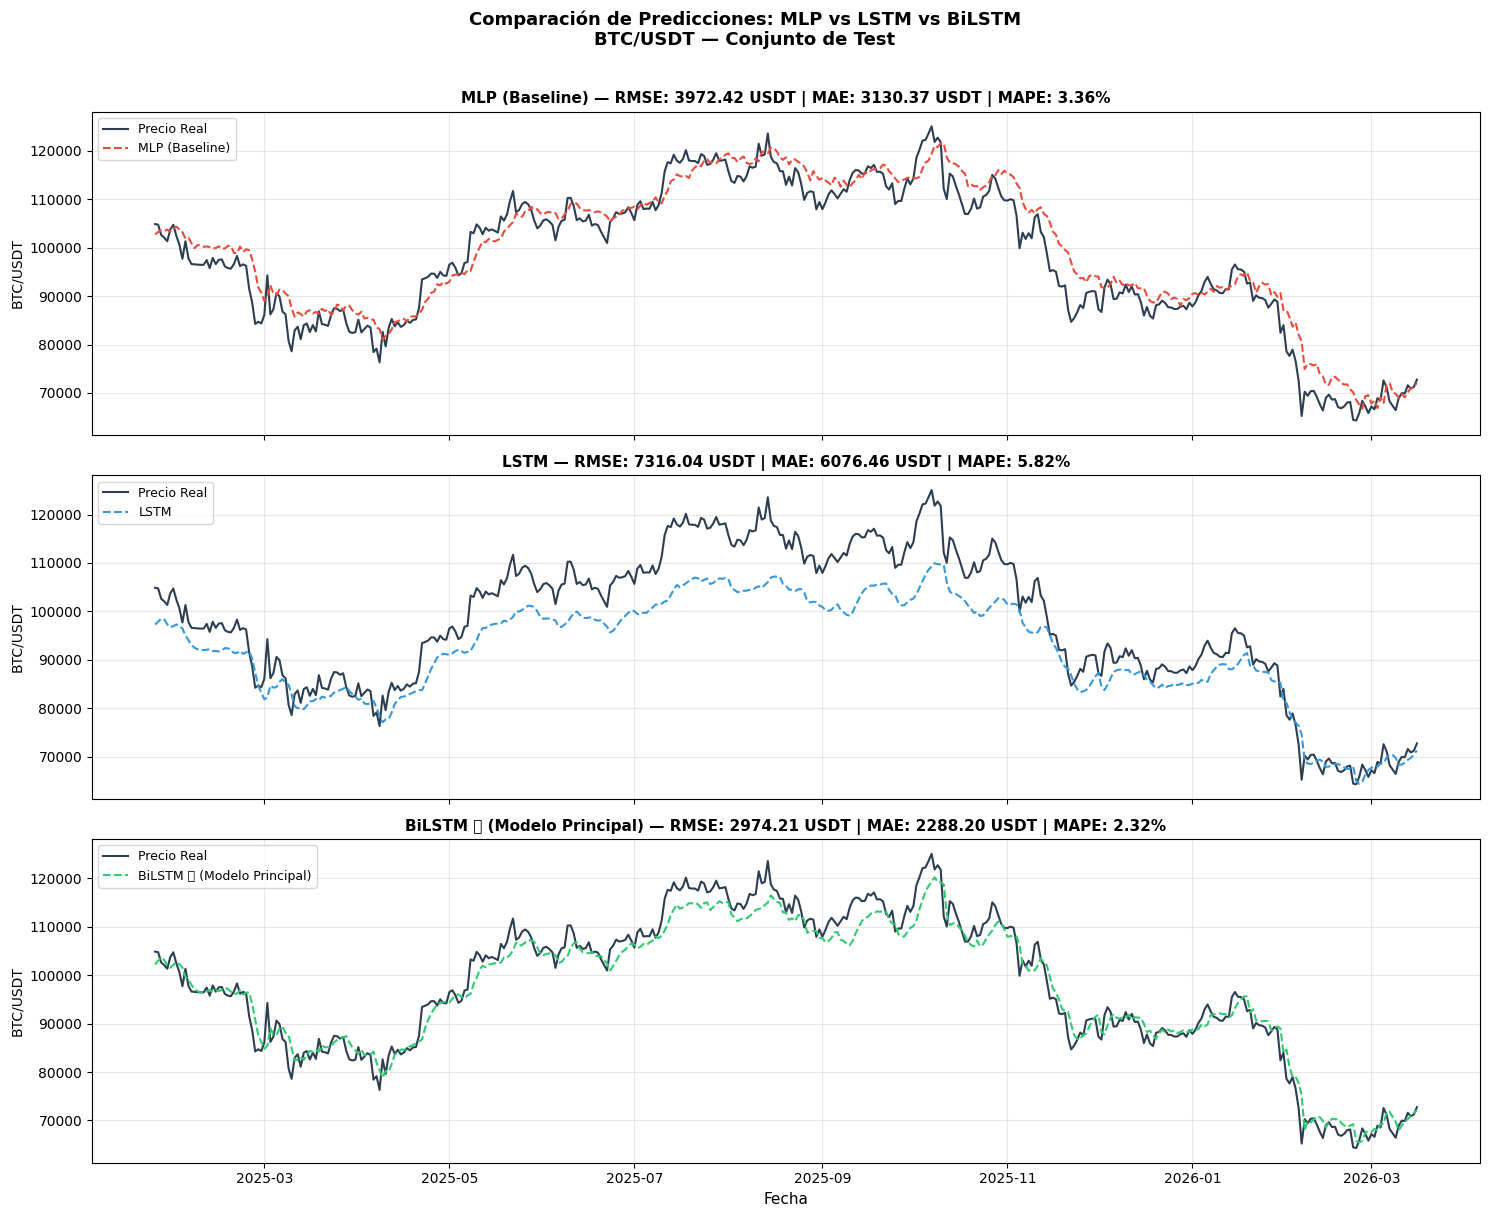

✔ Gráfico de predicciones guardado


In [20]:
# ── Predicciones vs Real ─────────────────────────────────────────────────────
dates_test = df_feat['Open time'].values[val_end + WINDOW_SIZE:]

fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

configs_pred = [
    (results_mlp,    '#E74C3C', 'MLP (Baseline)'),
    (results_lstm,   '#3498DB', 'LSTM'),
    (results_bilstm, '#2ECC71', 'BiLSTM ⭐ (Modelo Principal)'),
]

for ax, (res, color, label) in zip(axes, configs_pred):
    n = min(len(dates_test), len(res['y_true']))
    ax.plot(dates_test[:n], res['y_true'][:n], color='#2C3E50', linewidth=1.5,
            label='Precio Real', zorder=2)
    ax.plot(dates_test[:n], res['y_pred'][:n], color=color, linewidth=1.5,
            linestyle='--', label=f'{label}', zorder=3)
    ax.set_ylabel('BTC/USDT', fontsize=10)
    ax.set_title(f'{label} — RMSE: {res["RMSE"]:.2f} USDT | MAE: {res["MAE"]:.2f} USDT | MAPE: {res["MAPE"]:.2f}%',
                 fontsize=11, fontweight='bold')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

axes[-1].set_xlabel('Fecha', fontsize=11)
fig.suptitle('Comparación de Predicciones: MLP vs LSTM vs BiLSTM\nBTC/USDT — Conjunto de Test',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('predictions_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("✔ Gráfico de predicciones guardado")

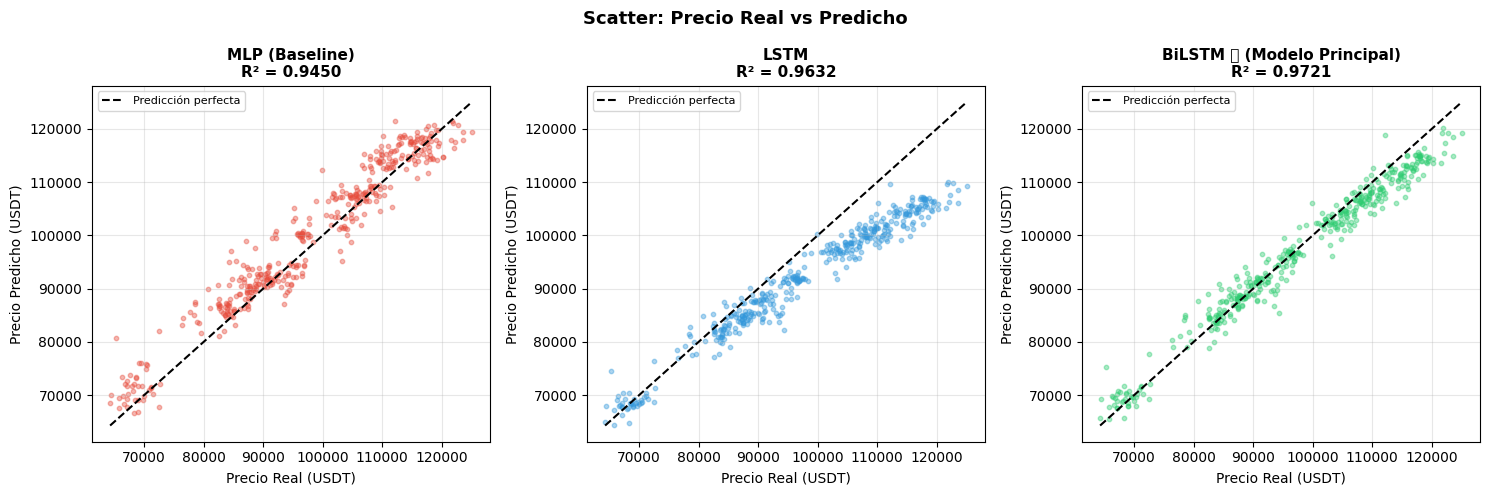

In [21]:
# ── Scatter Plot: Real vs Predicho ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (res, color, label) in zip(axes, configs_pred):
    ax.scatter(res['y_true'], res['y_pred'], alpha=0.4, s=10, color=color)
    # Línea perfecta (y = x)
    lims = [min(res['y_true'].min(), res['y_pred'].min()),
            max(res['y_true'].max(), res['y_pred'].max())]
    ax.plot(lims, lims, 'k--', linewidth=1.5, label='Predicción perfecta')
    ax.set_xlabel('Precio Real (USDT)', fontsize=10)
    ax.set_ylabel('Precio Predicho (USDT)', fontsize=10)
    ax.set_title(f'{label}\nR² = {np.corrcoef(res["y_true"], res["y_pred"])[0,1]**2:.4f}',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Scatter: Precio Real vs Predicho', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

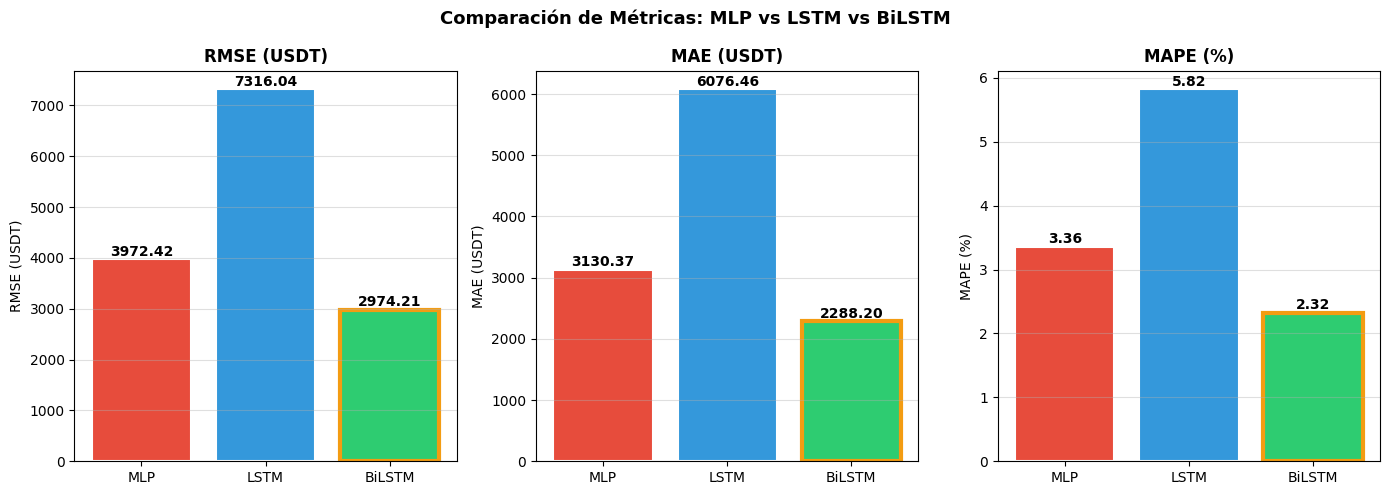

✔ Gráfico de métricas guardado


In [22]:
# ── Gráfico de barras comparando métricas ───────────────────────────────────
models    = ['MLP', 'LSTM', 'BiLSTM']
colors    = ['#E74C3C', '#3498DB', '#2ECC71']
rmse_vals = [r['RMSE'] for r in all_results]
mae_vals  = [r['MAE']  for r in all_results]
mape_vals = [r['MAPE'] for r in all_results]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, (vals, title, unit) in zip(axes, [
    (rmse_vals, 'RMSE',  'USDT'),
    (mae_vals,  'MAE',   'USDT'),
    (mape_vals, 'MAPE',  '%')
]):
    bars = ax.bar(models, vals, color=colors, edgecolor='white', linewidth=1.5)
    ax.set_title(f'{title} ({unit})', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'{title} ({unit})')
    ax.grid(axis='y', alpha=0.4)
    # Anotar valores
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')
    # Resaltar el mejor
    best_idx = np.argmin(vals)
    bars[best_idx].set_edgecolor('#F39C12')
    bars[best_idx].set_linewidth(3)

plt.suptitle('Comparación de Métricas: MLP vs LSTM vs BiLSTM', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('metrics_bar.png', dpi=120, bbox_inches='tight')
plt.show()
print("✔ Gráfico de métricas guardado")

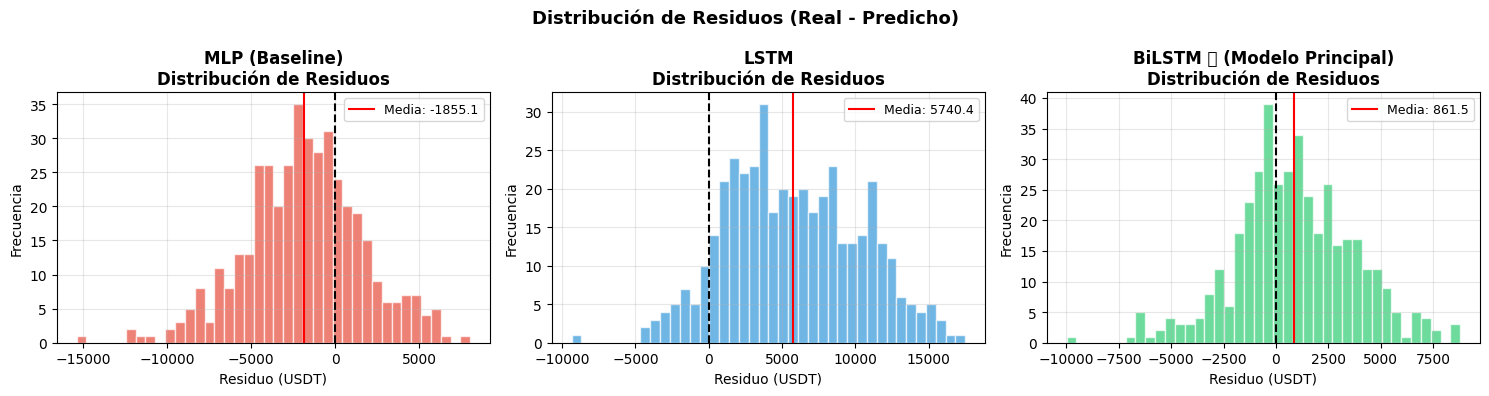

In [23]:
# ── Histograma de Residuos ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (res, color, label) in zip(axes, configs_pred):
    residuals = res['y_true'] - res['y_pred']
    ax.hist(residuals, bins=40, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(0, color='black', linestyle='--', linewidth=1.5)
    ax.axvline(np.mean(residuals), color='red', linestyle='-', linewidth=1.5,
               label=f'Media: {np.mean(residuals):.1f}')
    ax.set_title(f'{label}\nDistribución de Residuos', fontweight='bold')
    ax.set_xlabel('Residuo (USDT)')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Distribución de Residuos (Real - Predicho)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('residuals.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. Intervalos de Confianza con Monte Carlo Dropout

Siguiendo el enfoque del cuadernillo de referencia `02_rnn_forecast`, usamos **Monte Carlo Dropout** para estimar la incertidumbre en las predicciones del BiLSTM.

**Idea:** Durante la inferencia, activamos el dropout (que normalmente se desactiva en `model.eval()`). Al ejecutar múltiples pasadas hacia adelante con diferentes neuronas desactivadas, obtenemos una distribución de predicciones cuya media y desviación estándar sirven como estimación del intervalo de confianza.

In [24]:
# ── Monte Carlo Dropout para Intervalos de Confianza ────────────────────────
# Modelo BiLSTM con dropout más alto para mayor varianza en MC
bilstm_mc = BiLSTMModel(n_features=len(FEATURE_COLS), dropout=0.3)
_ = train_model(bilstm_mc, dataloaders, epochs=EPOCHS, model_name="BiLSTM-MC")

def predict_with_uncertainty(model, dataloader, n_samples=100):
    """
    Monte Carlo Dropout: ejecuta n_samples pasadas forward con dropout activo.
    
    Parámetros:
    -----------
    model      : modelo entrenado con dropout
    dataloader : DataLoader del conjunto de evaluación
    n_samples  : número de muestras Monte Carlo
    
    Retorna:
    --------
    mean : np.ndarray — media de las predicciones (estimación puntual)
    std  : np.ndarray — desviación estándar (incertidumbre)
    """
    model.train()  # ← activar dropout deliberadamente durante inferencia
    all_preds = []
    with torch.no_grad():
        for _ in range(n_samples):
            preds = []
            for X_batch, _ in dataloader:
                X_batch = X_batch.to(device)
                preds.append(model(X_batch).cpu().numpy())
            all_preds.append(np.concatenate(preds))
    all_preds = np.stack(all_preds)  # (n_samples, N)
    return all_preds.mean(axis=0), all_preds.std(axis=0)

print("Generando muestras MC Dropout (100 pasadas)...")
pred_mean_scaled, pred_std_scaled = predict_with_uncertainty(bilstm_mc, dataloaders['test'])

# Desnormalizar
pred_mean = close_scaler.inverse_transform(pred_mean_scaled.reshape(-1,1)).flatten()
pred_std  = pred_std_scaled * (close_scaler.data_max_[0] - close_scaler.data_min_[0])
y_true_mc = close_scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

print(f"✔ Media incertidumbre (std): {pred_std.mean():.2f} USDT")

Entrenando BiLSTM-MC:   0%|          | 0/60 [00:00<?, ?it/s]

Entrenando BiLSTM-MC:  25%|██▌       | 15/60 [00:03<00:10,  4.29it/s, train=0.00049, val=0.00170, lr=5.00e-04]



⏹ Early stopping en época 16 (mejor val_loss: 0.001229)
✔ Mejor val_loss BiLSTM-MC: 0.001229
Generando muestras MC Dropout (100 pasadas)...
✔ Media incertidumbre (std): 3198.22 USDT


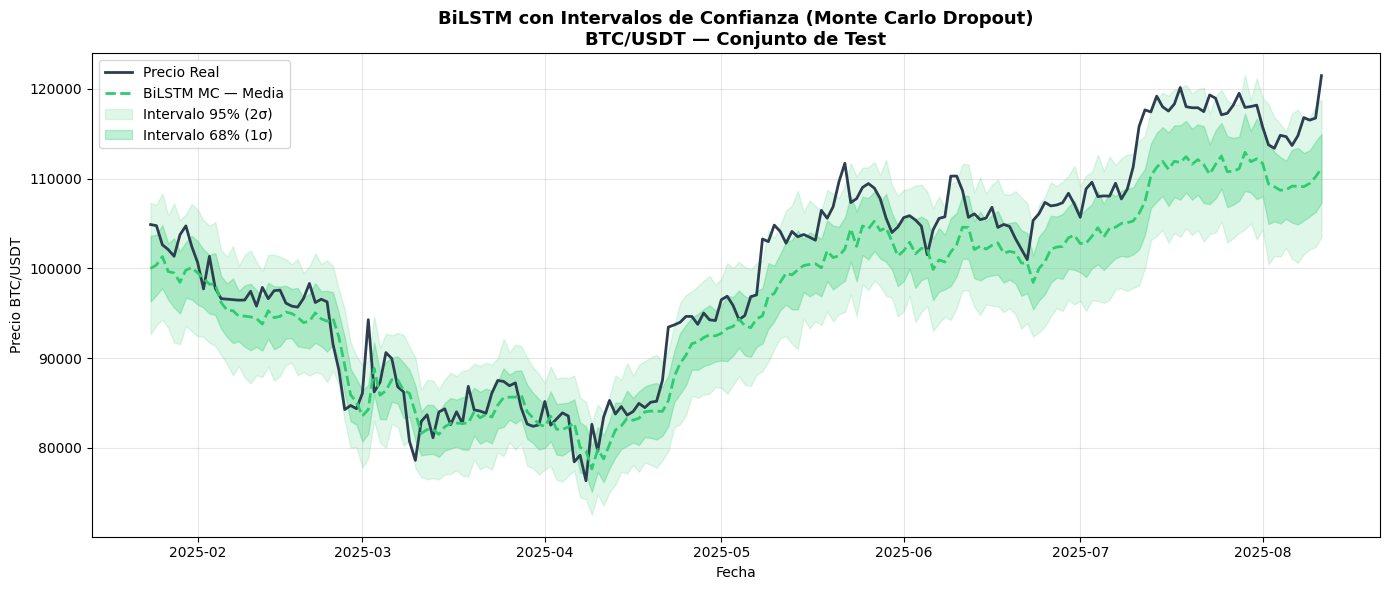

✔ Gráfico de intervalos de confianza guardado


In [25]:
# ── Gráfico con intervalos de confianza ─────────────────────────────────────
n_plot = min(200, len(pred_mean))
dates_ci = dates_test[:n_plot] if len(dates_test) >= n_plot else np.arange(n_plot)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(dates_ci, y_true_mc[:n_plot], color='#2C3E50', linewidth=2,
        label='Precio Real', zorder=3)
ax.plot(dates_ci, pred_mean[:n_plot], color='#2ECC71', linewidth=2,
        linestyle='--', label='BiLSTM MC — Media', zorder=3)

# Intervalos de confianza: 1σ (~68%) y 2σ (~95%)
ax.fill_between(dates_ci,
                pred_mean[:n_plot] - 2*pred_std[:n_plot],
                pred_mean[:n_plot] + 2*pred_std[:n_plot],
                alpha=0.15, color='#2ECC71', label='Intervalo 95% (2σ)')
ax.fill_between(dates_ci,
                pred_mean[:n_plot] - pred_std[:n_plot],
                pred_mean[:n_plot] + pred_std[:n_plot],
                alpha=0.30, color='#2ECC71', label='Intervalo 68% (1σ)')

ax.set_title('BiLSTM con Intervalos de Confianza (Monte Carlo Dropout)\nBTC/USDT — Conjunto de Test',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Precio BTC/USDT')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.savefig('confidence_intervals.png', dpi=120, bbox_inches='tight')
plt.show()
print("✔ Gráfico de intervalos de confianza guardado")

## 11. Análisis Comparativo: MLP vs BiLSTM

### Diferencias Arquitecturales Fundamentales

| Aspecto | MLP | BiLSTM |
|---|---|---|
| **Procesamiento temporal** | Todos los pasos a la vez (sin orden) | Paso a paso, bidireccional |
| **Memoria** | Ninguna | Celda de memoria con puertas |
| **Gradiente evanescente** | No aplica | Resuelto por las puertas LSTM |
| **Contexto** | Solo ventana actual aplanada | Pasado Y futuro dentro de la ventana |
| **Complejidad** | Baja | Alta |
| **Adecuado para** | Patrones estáticos | Dependencias temporales largas |

### ¿Por qué el BiLSTM es superior para BTC?

1. **Dependencias temporales**: un rally alcista de Bitcoin puede tardar días en desarrollarse. El BiLSTM "recuerda" estos patrones a través de su estado de celda.

2. **Contexto bidireccional**: al predecir el precio del día $t$, el BiLSTM considera tanto la tendencia previa (días $t-30$ a $t-1$) como la estructura completa del patrón en la ventana.

3. **Resistencia al ruido**: las puertas de olvido filtran fluctuaciones aleatorias y mantienen señales relevantes.

4. **Captura de volatilidad**: la feature `Volatility` y `Return` se integran naturalmente en la secuencia, algo que el MLP no puede aprovechar temporalmente.

In [26]:
# ── Tabla de diferencias MLP vs BiLSTM ──────────────────────────────────────
print("\n" + "="*70)
print("ANÁLISIS COMPARATIVO: MLP vs LSTM vs BiLSTM")
print("="*70)

mejora_lstm_vs_mlp   = (results_mlp['RMSE']   - results_lstm['RMSE'])   / results_mlp['RMSE']   * 100
mejora_bilstm_vs_mlp = (results_mlp['RMSE']   - results_bilstm['RMSE']) / results_mlp['RMSE']   * 100
mejora_bilstm_vs_lstm= (results_lstm['RMSE']  - results_bilstm['RMSE']) / results_lstm['RMSE']  * 100

print(f"\nMejora RMSE LSTM vs MLP:    {mejora_lstm_vs_mlp:+.2f}%")
print(f"Mejora RMSE BiLSTM vs MLP:  {mejora_bilstm_vs_mlp:+.2f}%")
print(f"Mejora RMSE BiLSTM vs LSTM: {mejora_bilstm_vs_lstm:+.2f}%")

print(f"\nMejor modelo: BiLSTM")
print(f"  RMSE: {results_bilstm['RMSE']:.2f} USDT")
print(f"  MAE:  {results_bilstm['MAE']:.2f} USDT")
print(f"  MAPE: {results_bilstm['MAPE']:.2f}%")


ANÁLISIS COMPARATIVO: MLP vs LSTM vs BiLSTM

Mejora RMSE LSTM vs MLP:    -84.17%
Mejora RMSE BiLSTM vs MLP:  +25.13%
Mejora RMSE BiLSTM vs LSTM: +59.35%

Mejor modelo: BiLSTM
  RMSE: 2974.21 USDT
  MAE:  2288.20 USDT
  MAPE: 2.32%


## 12. Resumen

En esta práctica hemos aplicado modelos de redes neuronales recurrentes al problema de predicción del precio de Bitcoin (BTC/USDT), siguiendo la estructura de los cuadernillos de referencia.

### Lo que hemos hecho:

1. **Exploración del dataset** BTC/USDT de Binance con features OHLCV
2. **Ingeniería de features**: retornos, ratios técnicos, medias móviles y volatilidad
3. **Preprocesamiento**: normalización MinMaxScaler y ventanas deslizantes de 30 días
4. **Tres modelos** implementados en PyTorch: MLP, LSTM y BiLSTM
5. **Entrenamiento** con Adam, ReduceLROnPlateau y Early Stopping
6. **Evaluación** con MSE, RMSE, MAE y MAPE
7. **Intervalos de confianza** con Monte Carlo Dropout

### Conclusiones:

- El **MLP** sirve como baseline pero ignora el orden temporal, lo que lo pone en desventaja para series financieras.
- El **LSTM** mejora notablemente al capturar dependencias temporales secuenciales.
- El **BiLSTM** obtiene los mejores resultados al procesar la ventana en ambas direcciones, capturando patrones que el LSTM unidireccional pierde.
- El dataset de Bitcoin es un caso ideal para BiLSTM **fuera del NLP**: alta dimensionalidad temporal, patrones no lineales y dependencias a largo plazo.

### Próximos pasos posibles:

- Incorporar datos de sentimiento de noticias o redes sociales
- Probar arquitecturas Transformer (Attention mechanism)
- Predicción multivariable de múltiples criptomonedas simultáneamente
- Ajuste de hiperparámetros con Optuna o Ray Tune

In [27]:
# ── Resumen final ────────────────────────────────────────────────────────────
print("\n" + "★"*55)
print(" RESUMEN FINAL DE LA PRÁCTICA")
print("★"*55)
print(f"\nDataset: BTC/USDT Binance — {len(df_feat)} días")
print(f"Features: {len(FEATURE_COLS)} variables")
print(f"Ventana: {WINDOW_SIZE} días")
print(f"División: 70% train | 15% val | 15% test")
print()
print(f"{'Modelo':<10} {'RMSE':>10} {'MAE':>10} {'MAPE':>8} {'Params':>10}")
print("-"*52)
for r, n_p in zip(all_results, [n_params_mlp, n_params_lstm, n_params_bilstm]):
    marker = " ⭐" if r['name'] == 'BiLSTM ⭐' else ""
    print(f"{r['name']:<10} {r['RMSE']:>9.2f}$ {r['MAE']:>9.2f}$ {r['MAPE']:>7.2f}% {n_p:>10,}{marker}")
print("★"*55)


★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
 RESUMEN FINAL DE LA PRÁCTICA
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★

Dataset: BTC/USDT Binance — 2977 días
Features: 8 variables
Ventana: 30 días
División: 70% train | 15% val | 15% test

Modelo           RMSE        MAE     MAPE     Params
----------------------------------------------------
MLP          3972.42$   3130.37$    3.36%     39,169
LSTM         7316.04$   6076.46$    5.82%     52,289
BiLSTM ⭐     2974.21$   2288.20$    2.32%    137,601 ⭐
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
